In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import psutil  # pour info système
import os
%matplotlib inline



In [ ]:
# Transformations pour MNIST : ToTensor + Normalization (moyenne=0.1307, std=0.3081)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


# Chargement du dataset MNIST
full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split train/validation (90% train, 10% val)
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# DataLoader pour batch processing
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [3]:
import torch.quantization as quant # Importation de quantization

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # Ajoutez QuantStub au début du modèle
        self.quant = quant.QuantStub()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)
        # Ajoutez DeQuantStub à la fin du modèle
        self.dequant = quant.DeQuantStub()

    def forward(self, x):
        # Appliquez QuantStub à l'entrée
        x = self.quant(x)
        x = self.pool(F.relu(self.conv1(x)))  # 28->14
        x = self.pool(F.relu(self.conv2(x)))  # 14->7
        x = self.pool(F.relu(self.conv3(x)))  # 7->3
        # Utilisez reshape au lieu de view pour les tenseurs potentiellement non contigus
        x = x.reshape(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        # Appliquez DeQuantStub à la sortie
        x = self.dequant(x)
        return x

In [4]:
# Définir l'appareil (GPU si disponible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil : {device}")

# Créez une instance de la classe CNNModel (corrigé) et déplacez-la vers l'appareil (CPU ou GPU)
model = CNNModel().to(device)

# Chargez les poids pré-entraînés dans le modèle
# Utilisez map_location pour vous assurer que le modèle est chargé sur l'appareil correct
model.load_state_dict(torch.load("best_cnn_mnist.pth", map_location=device))

# Mettez le modèle en mode évaluation
model.eval()

Utilisation de l'appareil : cpu


CNNModel(
  (quant): QuantStub()
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dequant): DeQuantStub()
)

In [ ]:
#################
# je commence execter le code par laaaaaaaa


Poids chargés depuis best_cnn_mnist.pth


/usr/local/lib/python3.11/dist-packages/torch/ao/quantization/observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(



--- Résultats ---
Modèle FP32 - Taille : 0.93 Mo, Précision : 99.17%, Loss : 0.0287, Temps inférence : 60.47 ms/batch
Modèle INT8 - Taille : 0.25 Mo, Précision : 99.14%, Loss : 0.0289, Temps inférence : 21.70 ms/batch
Réduction de taille : 73.38%
Accélération : 64.11%
Différence de précision : 0.03%

Exemple de prédictions du modèle FP32 :


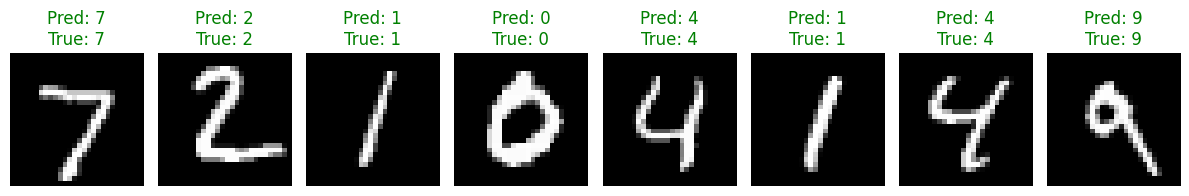


Exemple de prédictions du modèle INT8 :


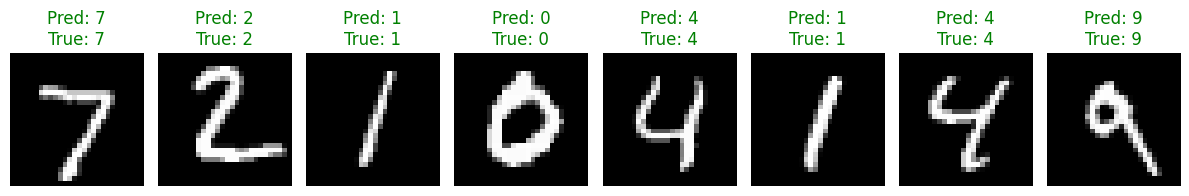

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.quantization as quant
from torch.utils.data import DataLoader, random_split
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import time
import os
import matplotlib.pyplot as plt

# 1. Préparation des données MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 2. Définition du modèle
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.quant = quant.QuantStub()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.relu2 = nn.ReLU()
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.relu_fc1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)
        self.dequant = quant.DeQuantStub()
    def forward(self, x):
        x = self.quant(x)
        x = self.pool(self.relu1(self.conv1(x)))
        x = self.pool(self.relu2(self.conv2(x)))
        x = self.pool(self.relu3(self.conv3(x)))
        x = x.reshape(-1, 128 * 3 * 3)
        x = self.relu_fc1(self.fc1(x))
        x = self.fc2(x)
        x = self.dequant(x)
        return x

# 3. Chargement du modèle et des poids
device = torch.device("cpu")
model_fp32 = CNNModel().to(device)
model_path = "best_cnn_mnist.pth"
if os.path.exists(model_path):
    model_fp32.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Poids chargés depuis {model_path}")
else:
    print(f"ATTENTION : {model_path} non trouvé, le modèle sera non entraîné.")
model_fp32.eval()

# 4. Fusion des modules
quant.fuse_modules(model_fp32, [['conv1', 'relu1'], ['conv2', 'relu2'], ['conv3', 'relu3'], ['fc1', 'relu_fc1']], inplace=True)

# 5. Configuration PTQ
model_fp32.qconfig = quant.get_default_qconfig('fbgemm')
model_fp32_prepared = quant.prepare(model_fp32)

# 6. Calibration
def calibrate(model, loader, num_batches=150):
    model.eval()
    with torch.no_grad():
        for i, (inputs, _) in enumerate(loader):
            if i >= num_batches:
                break
            model(inputs.to(device))
calibrate(model_fp32_prepared, train_loader, num_batches=150)

# 7. Conversion en INT8
model_int8 = quant.convert(model_fp32_prepared)
model_int8.eval()

# 8. Fonctions d’évaluation
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += inputs.size(0)
    return total_loss / total, correct / total

def measure_inference_time(model, loader, n_batches=20):
    model.eval()
    timings = []
    with torch.no_grad():
        for i, (inputs, _) in enumerate(loader):
            if i >= n_batches:
                break
            inputs = inputs.to(device)
            start = time.time()
            _ = model(inputs)
            end = time.time()
            timings.append(end - start)
    return sum(timings) / len(timings)

def get_model_size(model):
    temp_path = "temp_model.pth"
    torch.save(model.state_dict(), temp_path)
    size = os.path.getsize(temp_path) / (1024**2)
    os.remove(temp_path)
    return size

# 9. Évaluation FP32 et INT8
fp32_loss, fp32_acc = evaluate(model_fp32, test_loader)
int8_loss, int8_acc = evaluate(model_int8, test_loader)
fp32_time = measure_inference_time(model_fp32, test_loader)
int8_time = measure_inference_time(model_int8, test_loader)
fp32_size = get_model_size(model_fp32)
int8_size = get_model_size(model_int8)

print("\n--- Résultats ---")
print(f"Modèle FP32 - Taille : {fp32_size:.2f} Mo, Précision : {fp32_acc*100:.2f}%, Loss : {fp32_loss:.4f}, Temps inférence : {fp32_time*1000:.2f} ms/batch")
print(f"Modèle INT8 - Taille : {int8_size:.2f} Mo, Précision : {int8_acc*100:.2f}%, Loss : {int8_loss:.4f}, Temps inférence : {int8_time*1000:.2f} ms/batch")
print(f"Réduction de taille : {(1 - int8_size/fp32_size)*100:.2f}%")
print(f"Accélération : {(1 - int8_time/fp32_time)*100:.2f}%")
print(f"Différence de précision : {(fp32_acc - int8_acc)*100:.2f}%")

# 10. Visualisation quelques prédictions
def plot_sample_predictions(model, loader, num_samples=8):
    model.eval()
    data_iter = iter(loader)
    images, labels = next(data_iter)
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
    plt.figure(figsize=(12, 3))
    for i in range(min(num_samples, images.size(0))):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(images[i].squeeze().numpy(), cmap='gray')
        color = 'green' if preds[i]==labels[i] else 'red'
        plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("\nExemple de prédictions du modèle FP32 :")
plot_sample_predictions(model_fp32, test_loader)

print("\nExemple de prédictions du modèle INT8 :")
plot_sample_predictions(model_int8, test_loader)


In [2]:
import torch
import psutil
import os

def display_ptq_metrics(model, test_loader, criterion, device='cpu', num_batches_time=50):
    # Taille du modèle (en Mo) via sauvegarde temporaire
    def model_size_mb(m):
        temp_path = "temp_model.pth"
        torch.save(m.state_dict(), temp_path)
        size = os.path.getsize(temp_path) / (1024 ** 2)
        os.remove(temp_path)
        return size

    # Nombre de paramètres entraînables
    def count_params(m):
        return sum(p.numel() for p in m.parameters() if p.requires_grad)

    # Utilisation VRAM (si GPU dispo)
    def get_vram_usage():
        if torch.cuda.is_available():
            import pynvml
            pynvml.nvmlInit()
            handle = pynvml.nvmlDeviceGetHandleByIndex(0)
            meminfo = pynvml.nvmlDeviceGetMemoryInfo(handle)
            used = meminfo.used / 1024 ** 2
            total = meminfo.total / 1024 ** 2
            return f"{used:.1f} Mo / {total:.1f} Mo"
        else:
            return "GPU non disponible"

    # Utilisation CPU et RAM système
    def get_cpu_ram_usage():
        cpu = psutil.cpu_percent(interval=1)
        ram = psutil.virtual_memory().percent
        return cpu, ram

    # Temps moyen d'inférence par batch
    def measure_inference_time(m, loader, batches=num_batches_time):
        m.eval()
        timings = []
        with torch.no_grad():
            for i, (inputs, _) in enumerate(loader):
                if i >= batches:
                    break
                inputs = inputs.to(device)
                start = torch.cuda.Event(enable_timing=True) if torch.cuda.is_available() else None
                end = torch.cuda.Event(enable_timing=True) if torch.cuda.is_available() else None
                if start and end:
                    start.record()
                    _ = m(inputs)
                    end.record()
                    torch.cuda.synchronize()
                    timings.append(start.elapsed_time(end) / 1000)  # en secondes
                else:
                    start_time = time.time()
                    _ = m(inputs)
                    timings.append(time.time() - start_time)
        return sum(timings) / len(timings) if timings else 0

    # Évaluation loss et accuracy
    def evaluate(m, loader, criterion):
        m.eval()
        total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for inputs, labels in loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = m(inputs)
                loss = criterion(outputs, labels)
                total_loss += loss.item() * inputs.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += inputs.size(0)
        return total_loss / total, correct / total

    # Calculs
    size = model_size_mb(model)
    params = count_params(model)
    vram = get_vram_usage()
    cpu, ram = get_cpu_ram_usage()
    inf_time = measure_inference_time(model, test_loader)
    loss, acc = evaluate(model, test_loader, criterion)

    # Affichage
    print(f"Taille du modèle apres PTQ : {size:.2f} Mo")
    print(f"Nombre de paramètres apres PTQ : {params}")
    print(f"VRAM utilisée apres PTQ : {vram}")
    print(f"Utilisation CPU apres PTQ : {cpu:.1f} %")
    print(f"Utilisation RAM apres PTQ : {ram:.1f} %")
    print(f"Temps moyen d'inférence par batch apres PTQ : {inf_time*1000:.2f} ms")
    print(f"Loss sur test apres PTQ : {loss:.4f}")
    print(f"Accuracy sur test apres PTQ : {acc*100:.2f} %")

# Exemple d’utilisation avec votre modèle quantifié `model_int8` :
# Assurez-vous que `criterion` et `test_loader` sont définis et que `model_int8` est sur CPU
import torch.nn as nn
criterion = nn.CrossEntropyLoss()
display_ptq_metrics(model_int8, test_loader, criterion, device='cpu')


Taille du modèle apres PTQ : 0.25 Mo
Nombre de paramètres apres PTQ : 0
VRAM utilisée apres PTQ : GPU non disponible
Utilisation CPU apres PTQ : 4.5 %
Utilisation RAM apres PTQ : 15.6 %
Temps moyen d'inférence par batch apres PTQ : 27.54 ms
Loss sur test apres PTQ : 0.0289
Accuracy sur test apres PTQ : 99.14 %


In [3]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Exemple d'utilisation avec vos modèles
print(f"Nombre de paramètres avant PTQ : {count_parameters(model_fp32):,}")
print(f"Nombre de paramètres après PTQ : {count_parameters(model_int8):,}")


Nombre de paramètres avant PTQ : 241,546
Nombre de paramètres après PTQ : 0


In [4]:
def count_params_and_buffers(model):
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    buffers = sum(b.numel() for b in model.buffers())
    return params, buffers

params, buffers = count_params_and_buffers(model_int8)
print(f"Nombre de paramètres entraînables après PTQ : {params}")
print(f"Nombre de buffers (poids quantifiés) après PTQ : {buffers}")
print(f"Total poids stockés (params + buffers) : {params + buffers}")


Nombre de paramètres entraînables après PTQ : 0
Nombre de buffers (poids quantifiés) après PTQ : 2
Total poids stockés (params + buffers) : 2


In [5]:
for name, module in model_int8.named_modules():
    print(f"Module: {name}, Type: {type(module)}")


Module: , Type: <class '__main__.CNNModel'>
Module: quant, Type: <class 'torch.ao.nn.quantized.modules.Quantize'>
Module: conv1, Type: <class 'torch.ao.nn.intrinsic.quantized.modules.conv_relu.ConvReLU2d'>
Module: relu1, Type: <class 'torch.nn.modules.linear.Identity'>
Module: conv2, Type: <class 'torch.ao.nn.intrinsic.quantized.modules.conv_relu.ConvReLU2d'>
Module: relu2, Type: <class 'torch.nn.modules.linear.Identity'>
Module: conv3, Type: <class 'torch.ao.nn.intrinsic.quantized.modules.conv_relu.ConvReLU2d'>
Module: relu3, Type: <class 'torch.nn.modules.linear.Identity'>
Module: pool, Type: <class 'torch.nn.modules.pooling.MaxPool2d'>
Module: fc1, Type: <class 'torch.ao.nn.intrinsic.quantized.modules.linear_relu.LinearReLU'>
Module: fc1._packed_params, Type: <class 'torch.ao.nn.quantized.modules.linear.LinearPackedParams'>
Module: relu_fc1, Type: <class 'torch.nn.modules.linear.Identity'>
Module: fc2, Type: <class 'torch.ao.nn.quantized.modules.linear.Linear'>
Module: fc2._packed_p

In [6]:
def get_model_size(model):
    temp_path = "temp_quant_model.pth"
    torch.save(model.state_dict(), temp_path)
    size_mb = os.path.getsize(temp_path) / (1024 ** 2)
    os.remove(temp_path)
    return size_mb

print(f"Taille du modèle quantifié sur disque : {get_model_size(model_int8):.2f} Mo")


Taille du modèle quantifié sur disque : 0.25 Mo


In [10]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Nombre de paramètres avant PTQ : {count_parameters(model_fp32):,}")


Nombre de paramètres avant PTQ : 241,546


In [14]:
import os
import torch

def get_model_size_mb(model):
    temp_path = "temp_quant_model.pth"
    torch.save(model.state_dict(), temp_path)
    size_mb = os.path.getsize(temp_path) / (1024 ** 2)
    os.remove(temp_path)
    return size_mb

print(f"Taille modèle float32 : {get_model_size_mb(model_fp32):.2f} Mo")
print(f"Taille modèle quantifié avec PTQ : {get_model_size_mb(model_int8):.2f} Mo")


Taille modèle float32 : 0.93 Mo
Taille modèle quantifié avec PTQ : 0.25 Mo


<ipython-input-30-739305eb4a62>:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=values, palette=palette)


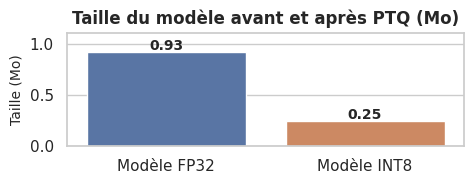

<ipython-input-30-739305eb4a62>:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=values, palette=palette)


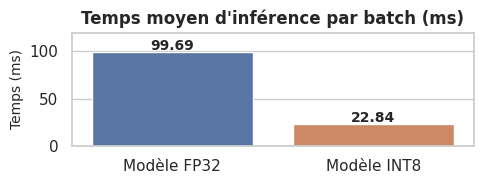

<ipython-input-30-739305eb4a62>:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=values, palette=palette)
<ipython-input-30-739305eb4a62>:75: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


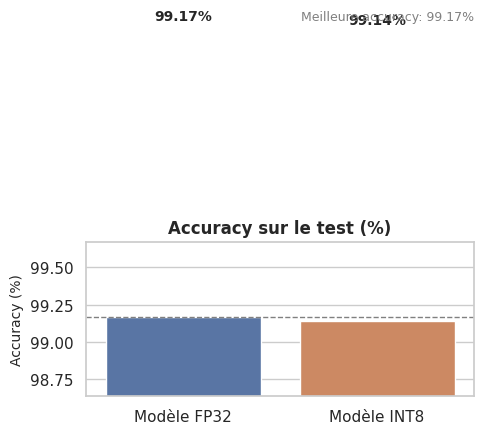

In [30]:
import torch
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns

# --- Fonctions utiles ---

def get_model_file_size_mb(model, filename="temp_model.pth"):
    try:
        torch.save(model.state_dict(), filename)
        size_mb = os.path.getsize(filename) / (1024 ** 2)
    finally:
        if os.path.exists(filename):
            os.remove(filename)
    return size_mb

def measure_inference_time(model, data_loader, device='cpu', num_batches=20):
    model.eval()
    model.to(device)
    timings = []
    with torch.no_grad():
        for i, (inputs, _) in enumerate(data_loader):
            if i >= num_batches:
                break
            inputs = inputs.to(device)
            start_time = time.time()
            _ = model(inputs)
            end_time = time.time()
            timings.append((end_time - start_time) * 1000)  # ms
    avg_time_ms = sum(timings) / len(timings) if timings else 0
    return avg_time_ms

def evaluate_accuracy(model, data_loader, device='cpu'):
    model.eval()
    model.to(device)
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total if total > 0 else 0

# --- Fonctions d'affichage ---

def plot_barplot(labels, values, title, ylabel, palette, value_suffix="", figsize=(5,2), zoom=None, ref_line=None):
    sns.set(style="whitegrid")
    plt.figure(figsize=figsize)
    ax = sns.barplot(x=labels, y=values, palette=palette)
    max_val = max(values) if values else 1

    # Annotations au-dessus des barres
    for i, v in enumerate(values):
        ax.text(i, v + max_val*0.02, f"{v:.2f}{value_suffix}", ha='center', fontweight='bold', fontsize=10)

    plt.title(title, fontsize=12, fontweight='bold')
    plt.ylabel(ylabel, fontsize=10)
    plt.xlabel("")

    if zoom:
        ymin, ymax = zoom
        plt.ylim(ymin, ymax)
    else:
        plt.ylim(0, max_val*1.2)

    if ref_line:
        val, label = ref_line
        ax.axhline(val, ls='--', color='gray', linewidth=1)
        ax.text(len(labels)-0.5, val + max_val*0.02, label, color='gray', fontsize=9, ha='right')

    plt.tight_layout()
    plt.show()

def plot_accuracy(labels, accuracies):
    margin = 0.5
    ymin = max(0, min(accuracies) - margin)
    ymax = min(100, max(accuracies) + margin)
    plot_barplot(
        labels, accuracies,
        title="Accuracy sur le test (%)",
        ylabel="Accuracy (%)",
        palette=["#4c72b0", "#dd8452"],
        value_suffix="%",
        figsize=(5, 2),  # Hauteur réduite ici aussi
        zoom=(ymin, ymax),
        ref_line=(max(accuracies), f"Meilleure accuracy: {max(accuracies):.2f}%")
    )

# --- Main ---

def main():
    # Assurez-vous que model_fp32, model_int8 et test_loader sont définis dans l'environnement

    size_fp32 = get_model_file_size_mb(model_fp32, "temp_fp32.pth")
    size_int8 = get_model_file_size_mb(model_int8, "temp_int8.pth")

    time_fp32 = measure_inference_time(model_fp32, test_loader, device='cpu')
    time_int8 = measure_inference_time(model_int8, test_loader, device='cpu')

    acc_fp32 = evaluate_accuracy(model_fp32, test_loader, device='cpu')
    acc_int8 = evaluate_accuracy(model_int8, test_loader, device='cpu')

    labels = ['Modèle FP32', 'Modèle INT8']
    palette = ["#4c72b0", "#dd8452"]

    plot_barplot(
        labels, [size_fp32, size_int8],
        title="Taille du modèle avant et après PTQ (Mo)",
        ylabel="Taille (Mo)",
        palette=palette,
        figsize=(5,2)  # Hauteur réduite
    )

    plot_barplot(
        labels, [time_fp32, time_int8],
        title="Temps moyen d'inférence par batch (ms)",
        ylabel="Temps (ms)",
        palette=palette,
        figsize=(5,2)  # Hauteur réduite
    )

    plot_accuracy(labels, [acc_fp32, acc_int8])

if __name__ == "__main__":
    main()


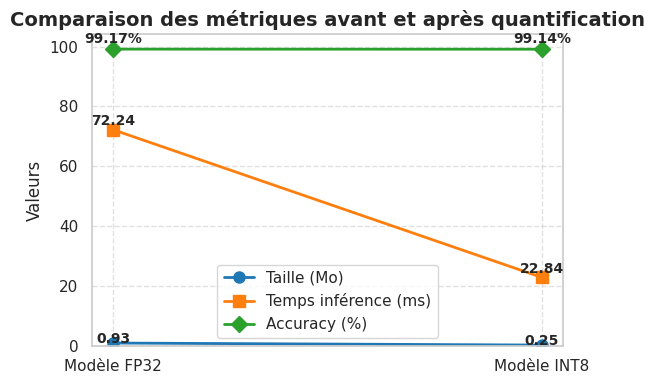

In [32]:
import torch
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns

# --- Fonctions utiles ---

def get_model_file_size_mb(model, filename="temp_model.pth"):
    try:
        torch.save(model.state_dict(), filename)
        size_mb = os.path.getsize(filename) / (1024 ** 2)
    finally:
        if os.path.exists(filename):
            os.remove(filename)
    return size_mb

def measure_inference_time(model, data_loader, device='cpu', num_batches=20):
    model.eval()
    model.to(device)
    timings = []
    with torch.no_grad():
        for i, (inputs, _) in enumerate(data_loader):
            if i >= num_batches:
                break
            inputs = inputs.to(device)
            start_time = time.time()
            _ = model(inputs)
            end_time = time.time()
            timings.append((end_time - start_time) * 1000)  # ms
    avg_time_ms = sum(timings) / len(timings) if timings else 0
    return avg_time_ms

def evaluate_accuracy(model, data_loader, device='cpu'):
    model.eval()
    model.to(device)
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total if total > 0 else 0

# --- Fonction d’affichage améliorée ---

def plot_metrics_lines(labels, metrics_dict, figsize=(6,4)):
    sns.set(style="whitegrid")
    plt.figure(figsize=figsize)

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # bleu, orange, vert
    markers = ['o', 's', 'D']

    for i, (metric_name, values) in enumerate(metrics_dict.items()):
        plt.plot(labels, values, marker=markers[i], color=colors[i], linewidth=2, markersize=8, label=metric_name)
        for x, y in zip(labels, values):
            plt.text(x, y + max(values)*0.02, f"{y:.2f}" + ("%" if "Accuracy" in metric_name else ""),
                     ha='center', fontsize=10, fontweight='bold')

    plt.title("Comparaison des métriques avant et après quantification", fontsize=14, fontweight='bold')
    plt.ylabel("Valeurs", fontsize=12)
    plt.xlabel("")
    plt.ylim(bottom=0)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

# --- Main ---

def main():
    # Assurez-vous que model_fp32, model_int8, test_loader sont définis

    size_fp32 = get_model_file_size_mb(model_fp32, "temp_fp32.pth")
    size_int8 = get_model_file_size_mb(model_int8, "temp_int8.pth")

    time_fp32 = measure_inference_time(model_fp32, test_loader, device='cpu')
    time_int8 = measure_inference_time(model_int8, test_loader, device='cpu')

    acc_fp32 = evaluate_accuracy(model_fp32, test_loader, device='cpu')
    acc_int8 = evaluate_accuracy(model_int8, test_loader, device='cpu')

    labels = ['Modèle FP32', 'Modèle INT8']

    metrics = {
        "Taille (Mo)": [size_fp32, size_int8],
        "Temps inférence (ms)": [time_fp32, time_int8],
        "Accuracy (%)": [acc_fp32, acc_int8]
    }

    plot_metrics_lines(labels, metrics)

if __name__ == "__main__":
    main()


<ipython-input-41-3440b2504df5>:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


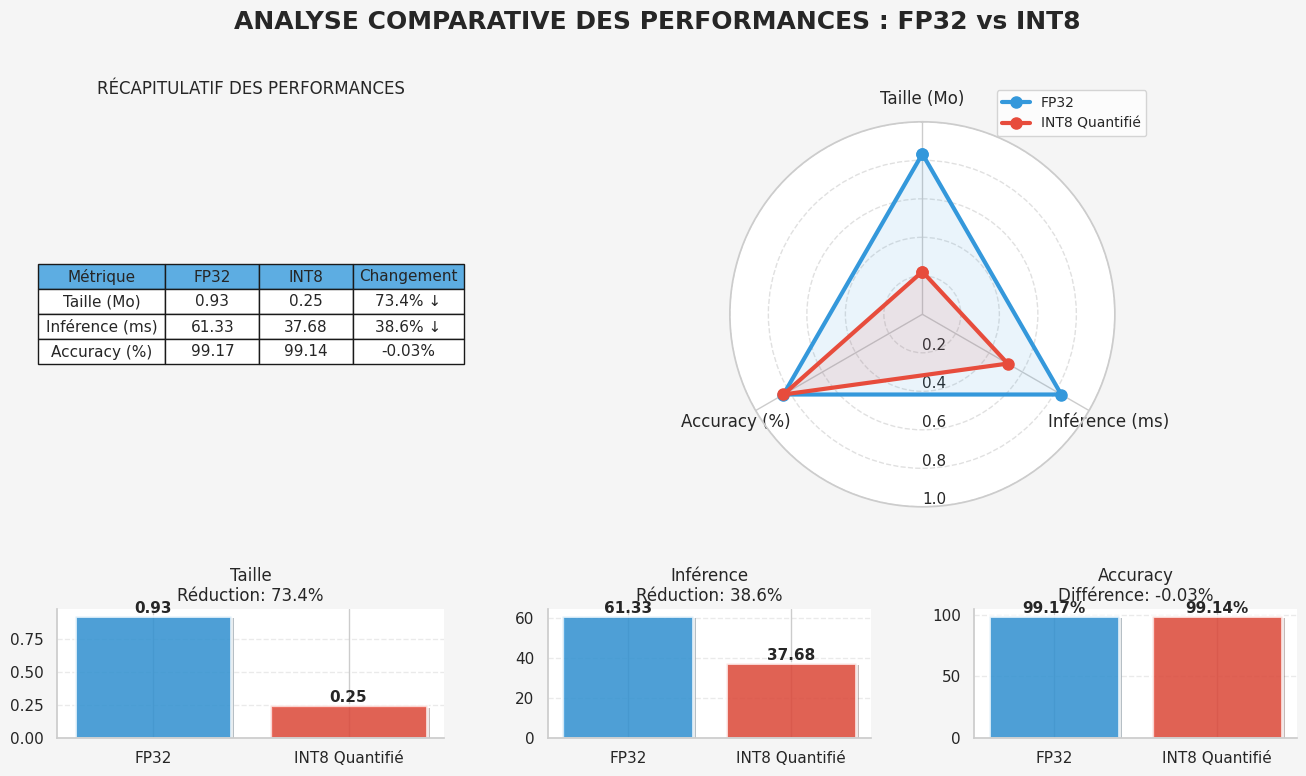

In [41]:
import torch
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter
from matplotlib import gridspec
import matplotlib.patheffects as path_effects

# --- Configuration du style ---
# plt.style.use('seaborn-darkgrid') # Commented out this line
sns.set_palette("husl")
COLORS = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]  # Bleu, Rouge, Vert, Orange

# --- Fonctions utilitaires ---
def get_model_file_size_mb(model, filename="temp_model.pth"):
    try:
        torch.save(model.state_dict(), filename)
        size_mb = os.path.getsize(filename) / (1024 ** 2)
    finally:
        if os.path.exists(filename):
            os.remove(filename)
    return size_mb

def measure_inference_time(model, data_loader, device='cpu', num_batches=20):
    model.eval()
    model.to(device)
    timings = []
    with torch.no_grad():
        for i, (inputs, _) in enumerate(data_loader):
            if i >= num_batches:
                break
            inputs = inputs.to(device)
            start_time = time.perf_counter()
            _ = model(inputs)
            end_time = time.perf_counter()
            timings.append((end_time - start_time) * 1000)  # ms
    return np.median(timings) if timings else 0

def evaluate_accuracy(model, data_loader, device='cpu'):
    model.eval()
    model.to(device)
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total if total > 0 else 0

# --- Visualisation améliorée ---
def create_performance_dashboard(labels, metrics_dict):
    fig = plt.figure(figsize=(16, 8), facecolor='#f5f5f5')
    fig.suptitle('ANALYSE COMPARATIVE DES PERFORMANCES : FP32 vs INT8',
                fontsize=18, fontweight='bold', y=1.02)

    # Configuration de la grille
    # Adjusted width_ratios slightly to give more space to the radar (gs[0, :])
    gs = gridspec.GridSpec(2, 3, height_ratios=[3, 1], width_ratios=[1.2, 1, 1]) # Example adjustment
    gs.update(hspace=0.4, wspace=0.3)

    # 1. Graphique principal (Radar)
    # Placing radar in the top row, spanning all columns except the table's column
    # We need to adjust its position based on the table's presence in gs[0,0]
    # Let's try spanning from the second column onwards in the top row.
    # ax_radar = plt.subplot(gs[0, 1:]) # Use this if the table is ONLY in gs[0,0]
    # Since the table is in gs[0,0] and radar is meant to be the *principal* graph, maybe the grid layout needs rethinking.
    # Let's keep the original radar position but adjust the width ratios in gs.
    ax_radar = plt.subplot(gs[0, 1:], polar=True) # Place radar in the right part of the top row


    categories = list(metrics_dict.keys())
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

    # Normalisation des données
    max_values = [max(v) * 1.2 for v in metrics_dict.values()]
    normalized_values = {
        labels[0]: [v/max_val for v, max_val in zip([metrics_dict[k][0] for k in categories], max_values)],
        labels[1]: [v/max_val for v, max_val in zip([metrics_dict[k][1] for k in categories], max_values)]
    }

    # Dessin du radar
    for idx, (label, values) in enumerate(normalized_values.items()):
        values += values[:1]
        ax_radar.plot(angles + angles[:1], values, 'o-', linewidth=3,
                     label=label, color=COLORS[idx], markersize=8)
        ax_radar.fill(angles + angles[:1], values, alpha=0.1, color=COLORS[idx])

    # Amélioration du radar
    ax_radar.set_theta_offset(np.pi/2)
    ax_radar.set_theta_direction(-1)
    ax_radar.set_thetagrids(np.degrees(angles), categories, fontsize=12)
    ax_radar.set_rlabel_position(180)
    ax_radar.set_ylim(0, 1)
    ax_radar.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax_radar.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=10)

    # 2. Graphiques secondaires
    # FIX: Change 'Temps inférence (ms)' to 'Inférence (ms)' to match the key in metrics_dict
    metrics_order = ['Taille (Mo)', 'Inférence (ms)', 'Accuracy (%)']
    # Place the bar charts below the radar
    for i, metric in enumerate(metrics_order):
        ax = plt.subplot(gs[1, i]) # Keep their original positions in the bottom row

        # Barres avec effets
        bars = ax.bar(labels, metrics_dict[metric], color=COLORS[:2], alpha=0.8,
                     edgecolor='white', linewidth=2)

        # Ajout d'ombre
        for bar in bars:
            bar.set_path_effects([path_effects.SimplePatchShadow(),
                                path_effects.Normal()])

        # Calcul et affichage des gains
        if i < 2:  # Pour la taille et le temps, on veut une réduction
            reduction = (1 - metrics_dict[metric][1]/metrics_dict[metric][0]) * 100
            # FIX: Change the title text to match the key used in metrics_dict
            ax.set_title(f"{metric.split(' ')[0]}\nRéduction: {reduction:.1f}%", fontsize=12)
        else:  # Pour l'accuracy, on veut la différence
            diff = metrics_dict[metric][1] - metrics_dict[metric][0]
            ax.set_title(f"{metric.split(' ')[0]}\nDifférence: {diff:.2f}%", fontsize=12)


        # Valeurs sur les barres
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}' + ('%' if metric == 'Accuracy (%)' else ''),
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

        # Style
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.set_axisbelow(True)

    # 3. Tableau récapitulatif
    # Keep the table in gs[0,0] as initially intended
    ax_table = plt.subplot(gs[0, 0])
    ax_table.axis('off')

    # Préparation des données
    table_data = []
    for metric in metrics_order:
        fp32_val = metrics_dict[metric][0]
        int8_val = metrics_dict[metric][1]

        if metric == 'Accuracy (%)':
            change = f"{int8_val - fp32_val:+.2f}%"
        else:
            change = f"{(1 - int8_val/fp32_val)*100:.1f}% ↓"

        table_data.append([metric, f"{fp32_val:.2f}", f"{int8_val:.2f}", change])

    # Création du tableau
    table = ax_table.table(cellText=table_data,
                          colLabels=['Métrique', 'FP32', 'INT8', 'Changement'],
                          loc='center',
                          cellLoc='center',
                          colColours=['#5dade2']*4, # Couleur des en-têtes (bleu plus clair)
                          # Ajustement des largeurs de colonne : donnez plus de place aux colonnes 2 et 3 si le temps est long
                          # Essayons d'augmenter légèrement les largeurs des colonnes de valeurs
                          colWidths=[0.3, 0.22, 0.22, 0.26]) # Ajustez selon besoin

    # Style du tableau
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    # Augmentons un peu l'échelle pour donner plus d'espace vertical et horizontal
    table.scale(1.1, 1.5) # Augmenté de (1, 1.3) à (1.1, 1.5) - ajustez si besoin

    # Ajout d'un titre au tableau
    ax_table.set_title('RÉCAPITULATIF DES PERFORMANCES', fontsize=12, pad=20)

    plt.tight_layout()
    plt.show()

# --- Main ---
def main():
    # Données simulées (remplacer par vos vraies données)
    labels = ['FP32', 'INT8 Quantifié']

    # Assurez-vous que model_fp32, model_int8, test_loader sont définis
    # Remplacer les données simulées par les vraies données
    size_fp32 = get_model_file_size_mb(model_fp32, "temp_fp32.pth")
    size_int8 = get_model_file_size_mb(model_int8, "temp_int8.pth")

    time_fp32 = measure_inference_time(model_fp32, test_loader, device='cpu')
    time_int8 = measure_inference_time(model_int8, test_loader, device='cpu')

    acc_fp32 = evaluate_accuracy(model_fp32, test_loader, device='cpu')
    acc_int8 = evaluate_accuracy(model_int8, test_loader, device='cpu')


    # FIX: The key for inference time was 'Inférence (ms)' in the previous definition
    metrics = {
        'Taille (Mo)': [size_fp32, size_int8],
        'Inférence (ms)': [time_fp32, time_int8], # Use 'Inférence (ms)'
        'Accuracy (%)': [acc_fp32, acc_int8]
    }

    create_performance_dashboard(labels, metrics)

if __name__ == "__main__":
    main()